In [3]:
%load_ext IPython.extensions.autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

In [2]:
import sys
sys.path.append('../../')
from model import FinData
from model import train_valid_test_split
from model import CatboostFinModel

import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import pandas as pd

/Users/Dasa/Desktop/Invest-Predict main/prices-predictions/prices-predictions/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Выгружаем лонг и шорт данные 

In [4]:
# Лонг

import pandas as pd
import datetime as dt

from catboost import CatBoostClassifier, Pool

args1 = {
    "iterations": 10000,
    "depth": 5,           # вот это!
    "use_best_model": True,
    "l2_leaf_reg": 200,     # вот это!
    "loss_function": 'Logloss',
    "eval_metric": 'Logloss',
    "cat_features": [],
    "random_state": 42,
    # "class_weights": [1, 0.25], НЕТУ ИХ!!
    "verbose": 0,
    "early_stopping_rounds": 500
}

companies_names = ['Gazprom']
dfs = ["../../datasets/" + stock + '_1_min.csv' for stock in companies_names]

cutoff_time = dt.datetime(2024, 2, 1)
start_time = dt.datetime(2024, 5, 1)
end_time = dt.datetime(2024, 12, 31)

for i in range(len(dfs)):
    res = pd.DataFrame()
    findata = FinData(dfs[i])
    findata.restrict_time_down(cutoff_time)
    findata.insert_all()

    cat_feats = findata.cat_features
    num_feats = findata.numeric_features
    target = 'direction_binary_0'
    
    curr_time = start_time
    company_name = companies_names[i]

    while curr_time < end_time:
        data = findata.df
        train_df = data[(data.utc >= curr_time - dt.timedelta(days=35)) & (data.utc <= curr_time - dt.timedelta(days=5))]
        val_df = data[(data.utc > curr_time - dt.timedelta(days=5)) & (data.utc <= curr_time)]
        test_df = data[(data.utc > curr_time) & (data.utc <= curr_time + dt.timedelta(days=5))]
        train_sd, val_sd, test_sd = train_df["utc"].iloc[0], val_df["utc"].iloc[0], test_df["utc"].iloc[0]
        train_ed, val_ed, test_ed = train_df["utc"].iloc[-1], val_df["utc"].iloc[-1], test_df["utc"].iloc[-1]
        print(f"Начало тренировочного периода: {train_sd}. Конец тренировочного периода: {train_ed} \n \
                    Начало валидационного периода: {val_sd}. Конец валидационного периода: {val_ed} \n \
                    Начало тестового периода: {test_sd}. Конец тестового периода: {test_ed} \n ")
        X_train, y_train = train_df[cat_feats + num_feats], train_df[target]
        X_val, y_val = val_df[cat_feats + num_feats], val_df[target]
        X_test, y_test = test_df[cat_feats + num_feats], test_df[target]

        model = CatBoostClassifier(**args1)

        # Передаем validation_set через eval_set
        model.fit(
            X_train, y_train,
            eval_set=Pool(X_val, y_val),
        )

        # Предсказания вероятностей класса 1
        proba = model.predict_proba(X_test)[:, 1]

        # Формирование блока с результатами
        temp_df = pd.DataFrame({
            'utc': test_df['utc'].values,
            'open': test_df['open'].values,
            'close': test_df['close'].values,
            'predicted_proba': proba
        })

        # Добавляем в общий DataFrame
        res = pd.concat([res, temp_df], ignore_index=True)

        # Сдвигаем окно
        curr_time += dt.timedelta(days=5)

    # Сохраняем результат по компании
    res.to_csv(f'{company_name}_long_valid.csv', index=False)


Начало тренировочного периода: 2024-03-27 07:00:00. Конец тренировочного периода: 2024-04-25 20:49:00 
                     Начало валидационного периода: 2024-04-26 07:00:00. Конец валидационного периода: 2024-04-30 20:49:00 
                     Начало тестового периода: 2024-05-01 07:01:00. Конец тестового периода: 2024-05-05 20:49:00 
 
Начало тренировочного периода: 2024-04-01 07:00:00. Конец тренировочного периода: 2024-04-30 20:49:00 
                     Начало валидационного периода: 2024-05-01 07:01:00. Конец валидационного периода: 2024-05-05 20:49:00 
                     Начало тестового периода: 2024-05-06 07:00:00. Конец тестового периода: 2024-05-10 20:49:00 
 
Начало тренировочного периода: 2024-04-06 07:01:00. Конец тренировочного периода: 2024-05-05 20:49:00 
                     Начало валидационного периода: 2024-05-06 07:00:00. Конец валидационного периода: 2024-05-10 20:49:00 
                     Начало тестового периода: 2024-05-11 07:01:00. Конец тестового пер

In [6]:
# Шорт

import pandas as pd
import datetime as dt

companies_names = ['Gazprom']
dfs = ["../../datasets/" + stock + '_1_min.csv' for stock in companies_names]

cutoff_time = dt.datetime(2024, 2, 1)
start_time = dt.datetime(2024, 5, 1)
end_time = dt.datetime(2024, 12, 31)

for i in range(len(dfs)):
    res = pd.DataFrame()
    findata = FinData(dfs[i])
    findata.restrict_time_down(cutoff_time)
    findata.insert_all()

    cat_feats = findata.cat_features
    num_feats = findata.numeric_features
    target = 'direction_binary_1'
    
    curr_time = start_time
    company_name = companies_names[i]

    while curr_time < end_time:
        data = findata.df
        train_df = data[(data.utc >= curr_time - dt.timedelta(days=35)) & (data.utc <= curr_time - dt.timedelta(days=5))]
        val_df = data[(data.utc > curr_time - dt.timedelta(days=5)) & (data.utc <= curr_time)]
        test_df = data[(data.utc > curr_time) & (data.utc <= curr_time + dt.timedelta(days=5))]
        train_sd, val_sd, test_sd = train_df["utc"].iloc[0], val_df["utc"].iloc[0], test_df["utc"].iloc[0]
        train_ed, val_ed, test_ed = train_df["utc"].iloc[-1], val_df["utc"].iloc[-1], test_df["utc"].iloc[-1]
        print(f"Начало тренировочного периода: {train_sd}. Конец тренировочного периода: {train_ed} \n \
                    Начало валидационного периода: {val_sd}. Конец валидационного периода: {val_ed} \n \
                    Начало тестового периода: {test_sd}. Конец тестового периода: {test_ed} \n ")
        X_train, y_train = train_df[cat_feats + num_feats], train_df[target]
        X_val, y_val = val_df[cat_feats + num_feats], val_df[target]
        X_test, y_test = test_df[cat_feats + num_feats], test_df[target]

        model = CatBoostClassifier(**args1)

        # Передаем validation_set через eval_set
        model.fit(
            X_train, y_train,
            eval_set=Pool(X_val, y_val),
        )

        # Предсказания вероятностей класса 1
        proba = model.predict_proba(X_test)[:, 1]

        # Формирование блока с результатами
        temp_df = pd.DataFrame({
            'utc': test_df['utc'].values,
            'open': test_df['open'].values,
            'close': test_df['close'].values,
            'predicted_proba': proba
        })

        # Добавляем в общий DataFrame
        res = pd.concat([res, temp_df], ignore_index=True)

        # Сдвигаем окно
        curr_time += dt.timedelta(days=5)

    # Сохраняем результат по компании
    res.to_csv(f'{company_name}_short_valid.csv', index=False)


Начало тренировочного периода: 2024-03-27 07:00:00. Конец тренировочного периода: 2024-04-25 20:49:00 
                     Начало валидационного периода: 2024-04-26 07:00:00. Конец валидационного периода: 2024-04-30 20:49:00 
                     Начало тестового периода: 2024-05-01 07:01:00. Конец тестового периода: 2024-05-05 20:49:00 
 
Начало тренировочного периода: 2024-04-01 07:00:00. Конец тренировочного периода: 2024-04-30 20:49:00 
                     Начало валидационного периода: 2024-05-01 07:01:00. Конец валидационного периода: 2024-05-05 20:49:00 
                     Начало тестового периода: 2024-05-06 07:00:00. Конец тестового периода: 2024-05-10 20:49:00 
 
Начало тренировочного периода: 2024-04-06 07:01:00. Конец тренировочного периода: 2024-05-05 20:49:00 
                     Начало валидационного периода: 2024-05-06 07:00:00. Конец валидационного периода: 2024-05-10 20:49:00 
                     Начало тестового периода: 2024-05-11 07:01:00. Конец тестового пер

Выгружаем графики метрик

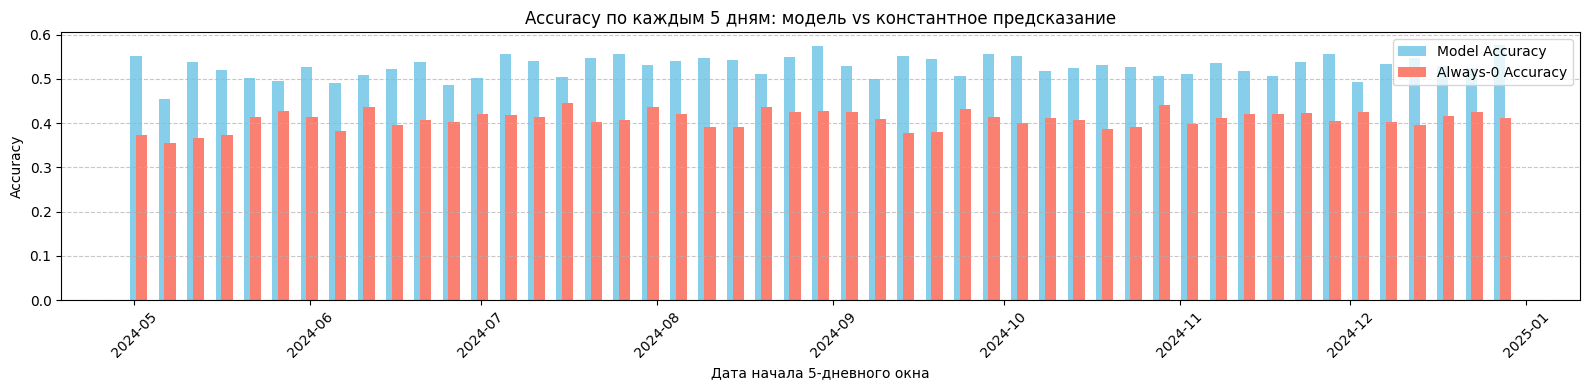

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Загрузка и подготовка данных
data = pd.read_csv('Gazprom_long_valid.csv')
data['utc'] = pd.to_datetime(data['utc'])
data = data.sort_values('utc')

# Целевая переменная: будет ли close расти на следующей минуте
data['target'] = (data['close'].shift(-1) >= data['close']).astype(int)

# Предсказания модели
threshold = 0.5
data['pred'] = (data['predicted_proba'] > threshold).astype(int)

# Создаем группы по 5 дней
data['group_id'] = ((data['utc'] - data['utc'].min()).dt.days // 5)

# Функция для расчёта accuracy модели и accuracy "всегда 0"
def compute_group_accuracy(group):
    acc_model = accuracy_score(group['target'], group['pred'])
    acc_dummy0 = accuracy_score(group['target'], [0] * len(group))
    return pd.Series({'accuracy_model': acc_model, 'accuracy_dummy0': acc_dummy0})

# Применяем по группам
grouped_accuracy = data.groupby('group_id').apply(compute_group_accuracy).reset_index()

# Добавим дату начала группы
grouped_accuracy['start_date'] = data.groupby('group_id')['utc'].min().values

# Строим barplot
plt.figure(figsize=(16, 4))
bar_width = 4  # Ширина одного столбца (в днях на оси X)

# Координаты по оси X
x = grouped_accuracy['start_date']

# Столбцы с accuracy модели (слева) и dummy (чуть правее)
plt.bar(x, grouped_accuracy['accuracy_model'], 
        width=2, label='Model Accuracy', color='skyblue', align='center')

plt.bar(x, grouped_accuracy['accuracy_dummy0'], 
        width=2, label='Always-0 Accuracy', color='salmon', align='edge')

# Подписи и оформление
plt.title('Accuracy по каждым 5 дням: модель vs константное предсказание')
plt.xlabel('Дата начала 5-дневного окна')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

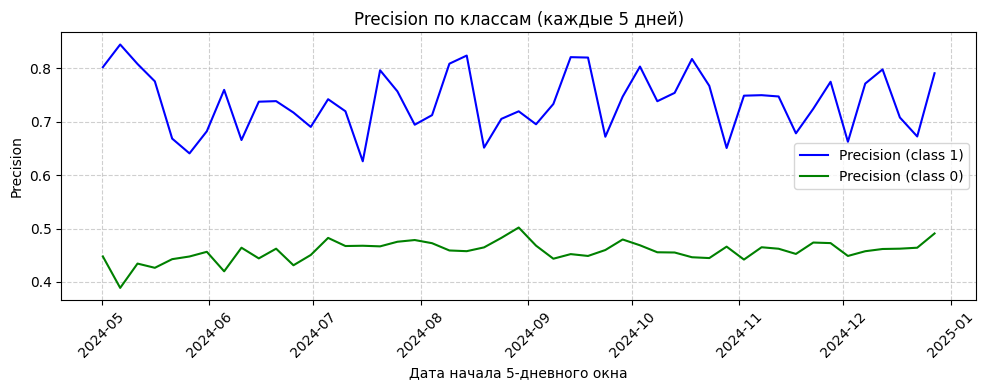

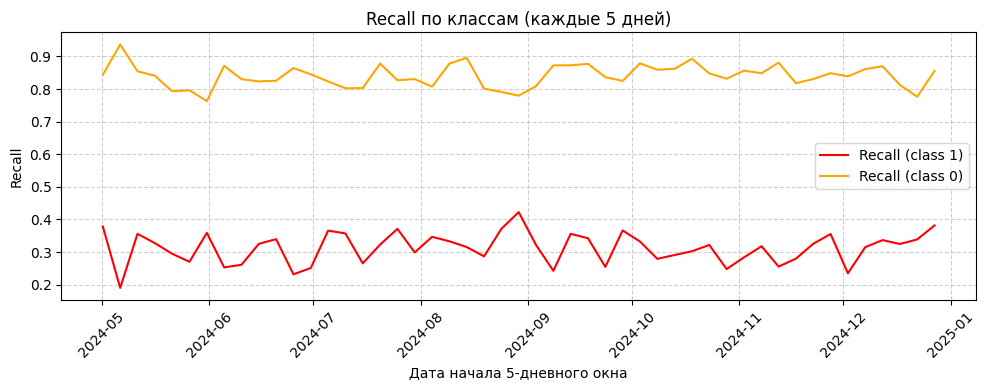

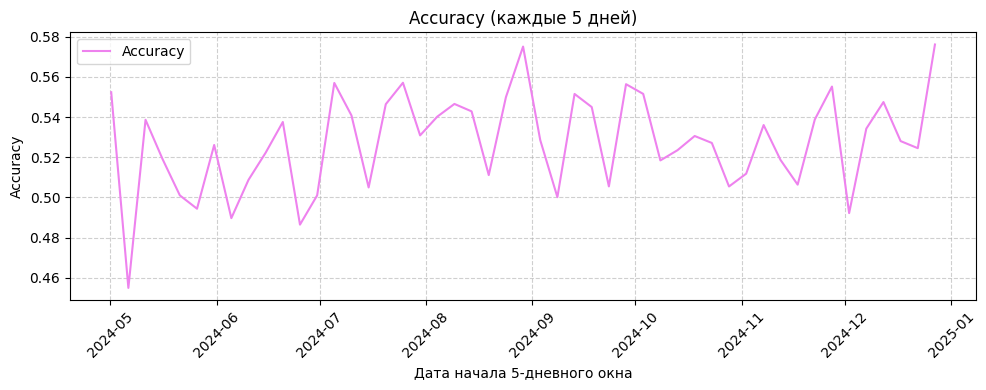

In [10]:
from sklearn.metrics import precision_score, recall_score, accuracy_score

# Загрузка и подготовка данных
data = pd.read_csv('Gazprom_long_valid.csv')
data['utc'] = pd.to_datetime(data['utc'])
data = data.sort_values('utc')

# Целевая переменная: будет ли close расти на следующей минуте
data['target'] = (data['close'].shift(-1) >= data['close']).astype(int)

# Предсказания модели
threshold = 0.5
data['pred'] = (data['predicted_proba'] > threshold).astype(int)

# Группировка по 5-дневным окнам
data['group_id'] = ((data['utc'] - data['utc'].min()).dt.days // 5)

# Функция для расчета precision и recall по классам
def compute_precision_recall(group):
    y_true = group['target']
    y_pred = group['pred']
    accuracy = accuracy_score(y_true, y_pred)
    precision_1 = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    precision_0 = precision_score(y_true, y_pred, pos_label=0, zero_division=0)
    recall_1 = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    recall_0 = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    return pd.Series({
        'precision_1': precision_1,
        'precision_0': precision_0,
        'recall_1': recall_1,
        'recall_0': recall_0,
        'accuracy':  accuracy
    })

# Применяем по группам
metrics_by_group = data.groupby('group_id').apply(compute_precision_recall).reset_index()

# Добавим дату начала каждой группы
metrics_by_group['start_date'] = data.groupby('group_id')['utc'].min().values

# ----------------------- #
# 1. График Precision     #
# ----------------------- #
plt.figure(figsize=(10, 4))
plt.plot(metrics_by_group['start_date'], metrics_by_group['precision_1'], label='Precision (class 1)', color='blue')
plt.plot(metrics_by_group['start_date'], metrics_by_group['precision_0'], label='Precision (class 0)', color='green')
plt.title('Precision по классам (каждые 5 дней)')
plt.xlabel('Дата начала 5-дневного окна')
plt.ylabel('Precision')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ----------------------- #
# 2. График Recall        #
# ----------------------- #
plt.figure(figsize=(10, 4))
plt.plot(metrics_by_group['start_date'], metrics_by_group['recall_1'], label='Recall (class 1)', color='red')
plt.plot(metrics_by_group['start_date'], metrics_by_group['recall_0'], label='Recall (class 0)', color='orange')
plt.title('Recall по классам (каждые 5 дней)')
plt.xlabel('Дата начала 5-дневного окна')
plt.ylabel('Recall')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ----------------------- #
# 3. График Accuracy       #
# ----------------------- #
plt.figure(figsize=(10, 4))
plt.plot(metrics_by_group['start_date'], metrics_by_group['accuracy'], label='Accuracy', color='violet')
plt.title('Accuracy (каждые 5 дней)')
plt.xlabel('Дата начала 5-дневного окна')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

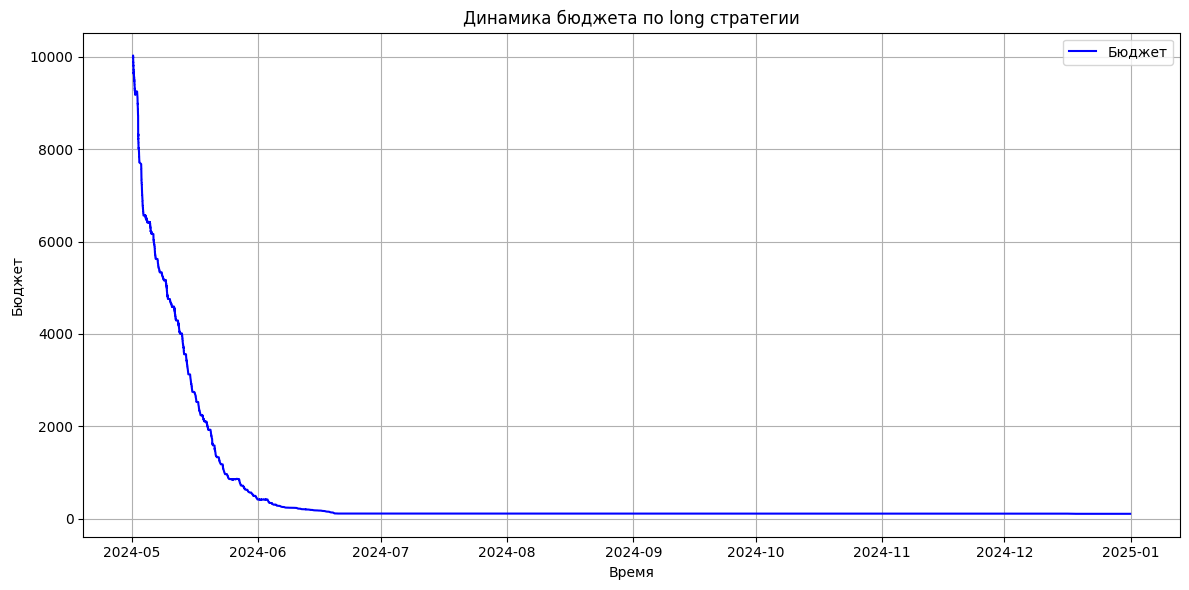

In [11]:
merged = data

# Добавим колонку close_{t+1}
merged['close_t+1'] = merged['close'].shift(-1)

df = merged

df['predicted_class'] = df['pred']

# Параметры
initial_budget = 10000
commission_rate = 0.0004

budget = initial_budget
budget_history = [budget]
timestamps = [df['utc'].iloc[0]]

for i in range(len(df) - 1):
    # continue
    row = df.iloc[i]
    next_row = df.iloc[i + 1]

    price_now = row['close']
    price_next = next_row['close']
    signal = row['predicted_class']

    if signal == 1:  # Long
        n_shares = int(budget // price_now)
        if n_shares == 0:
            pass
        else:
            buy_cost = n_shares * price_now * (1 + commission_rate)
            sell_revenue = n_shares * price_next * (1 - commission_rate)
            budget += sell_revenue - buy_cost

    # if signal == 0:  # Short
    #     n_shares = int(budget // price_now)
    #     if n_shares == 0:
    #         pass
    #     else:
    #         sell_proceeds = n_shares * price_now * (1 - commission_rate)
    #         buy_cost = n_shares * price_next * (1 + commission_rate)
    #         budget += sell_proceeds - buy_cost

    # Если signal == 0 — ничего не делаем
    budget_history.append(budget)
    timestamps.append(next_row['utc'])

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(timestamps, budget_history, label='Бюджет', color='blue')
plt.xlabel('Время')
plt.ylabel('Бюджет')
plt.title('Динамика бюджета по long стратегии')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

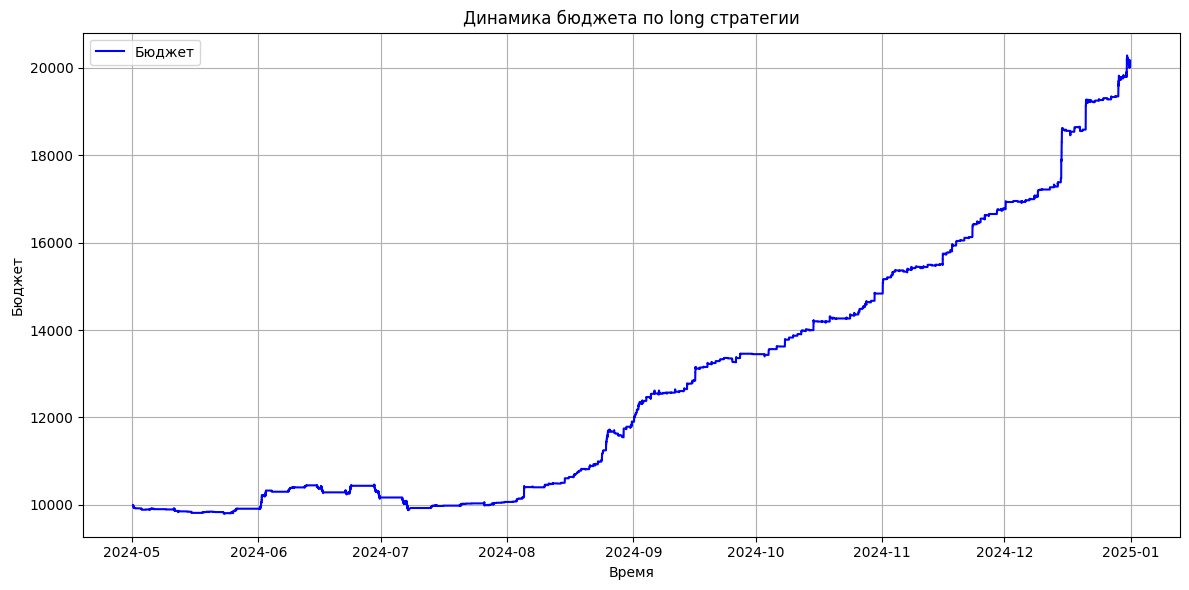

In [18]:
merged = data

# Добавим колонку close_{t+1}
merged['close_t+1'] = merged['close'].shift(-1)

df = merged

df['predicted_class'] = (data['predicted_proba'] > .75).astype(int)

# Параметры
initial_budget = 10000
commission_rate = 0.0004

budget = initial_budget
budget_history = [budget]
timestamps = [df['utc'].iloc[0]]

for i in range(len(df) - 1):
    # continue
    row = df.iloc[i]
    next_row = df.iloc[i + 1]

    price_now = row['close']
    price_next = next_row['close']
    signal = row['predicted_class']

    if signal == 1:  # Long
        n_shares = int(budget // price_now)
        if n_shares == 0:
            pass
        else:
            buy_cost = n_shares * price_now * (1 + commission_rate)
            sell_revenue = n_shares * price_next * (1 - commission_rate)
            budget += sell_revenue - buy_cost

    # if signal == 0:  # Short
    #     n_shares = int(budget // price_now)
    #     if n_shares == 0:
    #         pass
    #     else:
    #         sell_proceeds = n_shares * price_now * (1 - commission_rate)
    #         buy_cost = n_shares * price_next * (1 + commission_rate)
    #         budget += sell_proceeds - buy_cost

    # Если signal == 0 — ничего не делаем
    budget_history.append(budget)
    timestamps.append(next_row['utc'])

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(timestamps, budget_history, label='Бюджет', color='blue')
plt.xlabel('Время')
plt.ylabel('Бюджет')
plt.title('Динамика бюджета по long стратегии')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

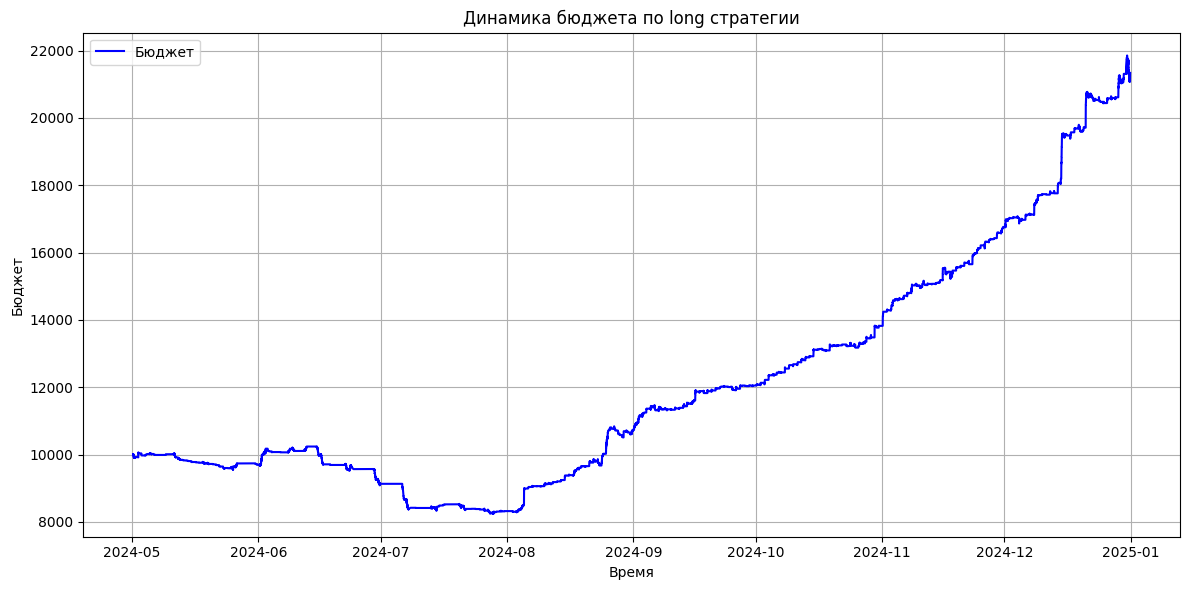

In [17]:
merged = data

# Добавим колонку close_{t+1}
merged['close_t+1'] = merged['close'].shift(-1)

df = merged

df['predicted_class'] = (data['predicted_proba'] > .7).astype(int)

# Параметры
initial_budget = 10000
commission_rate = 0.0004

budget = initial_budget
budget_history = [budget]
timestamps = [df['utc'].iloc[0]]

for i in range(len(df) - 1):
    # continue
    row = df.iloc[i]
    next_row = df.iloc[i + 1]

    price_now = row['close']
    price_next = next_row['close']
    signal = row['predicted_class']

    if signal == 1:  # Long
        n_shares = int(budget // price_now)
        if n_shares == 0:
            pass
        else:
            buy_cost = n_shares * price_now * (1 + commission_rate)
            sell_revenue = n_shares * price_next * (1 - commission_rate)
            budget += sell_revenue - buy_cost

    # if signal == 0:  # Short
    #     n_shares = int(budget // price_now)
    #     if n_shares == 0:
    #         pass
    #     else:
    #         sell_proceeds = n_shares * price_now * (1 - commission_rate)
    #         buy_cost = n_shares * price_next * (1 + commission_rate)
    #         budget += sell_proceeds - buy_cost

    # Если signal == 0 — ничего не делаем
    budget_history.append(budget)
    timestamps.append(next_row['utc'])

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(timestamps, budget_history, label='Бюджет', color='blue')
plt.xlabel('Время')
plt.ylabel('Бюджет')
plt.title('Динамика бюджета по long стратегии')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()